<a href="https://colab.research.google.com/github/cliteka-cell/Absolute-Range-Moving-Average-Strategy/blob/main/Absolute_Range_SD_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 1. Download data (We need High, Low, and Close now)
print("Downloading 1-minute futures data...")
df = yf.download("ES=F", period="7d", interval="1m")
df = df[['High', 'Low', 'Close']].copy()

# 1. Shorter window for faster reaction
window = 30

# 2. Use EMA (Exponential Moving Average) for the Range
# ewm(span=window) tells Pandas to give more weight to recent prices
df['Top_Range'] = df['High'].ewm(span=window, adjust=False).mean()
df['Bottom_Range'] = df['Low'].ewm(span=window, adjust=False).mean()

# Calculate the standard deviation of the closing price
df['Std'] = df['Close'].rolling(window=window).std()

# 3. Add Standard Deviations to the TOP of the range (For Short Selling)
df['Upper_1'] = df['Top_Range'] + (df['Std'] * 1)
df['Upper_2'] = df['Top_Range'] + (df['Std'] * 2)
df['Upper_3'] = df['Top_Range'] + (df['Std'] * 3)
df['Stop_High'] = df['Top_Range'] + (df['Std'] * 4)

# 4. Subtract Standard Deviations from the BOTTOM of the range (For Buying)
df['Lower_1'] = df['Bottom_Range'] - (df['Std'] * 1)
df['Lower_2'] = df['Bottom_Range'] - (df['Std'] * 2)
df['Lower_3'] = df['Bottom_Range'] - (df['Std'] * 3)
df['Stop_Low'] = df['Bottom_Range'] - (df['Std'] * 4)

df = df.dropna()
print("Range math complete.")

/tmp/ipykernel_432/1278467391.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("ES=F", period="7d", interval="1m")
[*********************100%***********************]  1 of 1 completed

Range math complete.


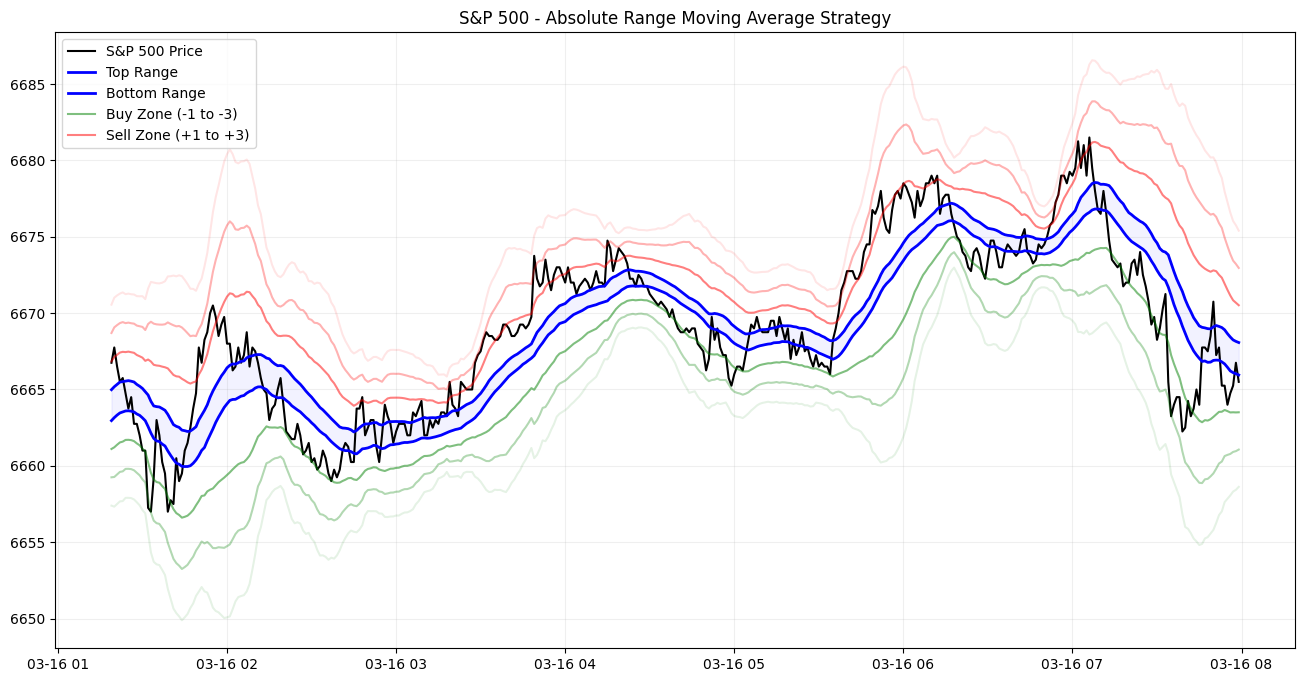

In [29]:
# Plot the last 400 minutes again to keep it readable
plot_df = df.iloc[-400:]

plt.figure(figsize=(16, 8))

# Actual Price
plt.plot(plot_df.index, plot_df['Close'], label='S&P 500 Price', color='black', linewidth=1.5)

# The "No Trade Zone" Range
plt.plot(plot_df.index, plot_df['Top_Range'], color='blue', linewidth=2, label='Top Range')
plt.plot(plot_df.index, plot_df['Bottom_Range'], color='blue', linewidth=2, label='Bottom Range')
plt.fill_between(plot_df.index, plot_df['Top_Range'], plot_df['Bottom_Range'], color='blue', alpha=0.05)

# Buying Zones (Under the Bottom Range)
plt.plot(plot_df.index, plot_df['Lower_1'], color='green', alpha=0.5, label='Buy Zone (-1 to -3)')
plt.plot(plot_df.index, plot_df['Lower_2'], color='green', alpha=0.3)
plt.plot(plot_df.index, plot_df['Lower_3'], color='green', alpha=0.1)

# Selling Zones (Above the Top Range)
plt.plot(plot_df.index, plot_df['Upper_1'], color='red', alpha=0.5, label='Sell Zone (+1 to +3)')
plt.plot(plot_df.index, plot_df['Upper_2'], color='red', alpha=0.3)
plt.plot(plot_df.index, plot_df['Upper_3'], color='red', alpha=0.1)

plt.title('S&P 500 - Absolute Range Moving Average Strategy')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

In [36]:
detailed_trades = []
long_inventory = []
short_inventory = []

# Our two optimization rules
bad_hours = [23, 2, 4, 6, 7]
min_width = 2.0

for i in range(len(df)):
    price = df['Close'].iloc[i].item()
    current_time = df.index[i]
    current_hour = current_time.hour

    top_range = df['Top_Range'].iloc[i]
    bot_range = df['Bottom_Range'].iloc[i]
    range_width = top_range - bot_range

    l1, l2, l3 = df['Lower_1'].iloc[i], df['Lower_2'].iloc[i], df['Lower_3'].iloc[i]
    stop_low = df['Stop_Low'].iloc[i]

    u1, u2, u3 = df['Upper_1'].iloc[i], df['Upper_2'].iloc[i], df['Upper_3'].iloc[i]
    stop_high = df['Stop_High'].iloc[i]

    # --- BUY LOGIC (LONG) ---
    if price <= stop_low and len(long_inventory) > 0:
        for entry_time, entry_price in long_inventory:
            detailed_trades.append({'Profit': (price - entry_price) / entry_price})
        long_inventory = []

    elif price >= bot_range and len(long_inventory) > 0:
        for entry_time, entry_price in long_inventory:
            detailed_trades.append({'Profit': (price - entry_price) / entry_price})
        long_inventory = []

    # NEW RULE: Check the hour AND the width of the pipe
    elif current_hour not in bad_hours and range_width >= min_width:
        if price <= l3 and len(long_inventory) == 2:
            long_inventory.append((current_time, price))
        elif price <= l2 and len(long_inventory) == 1:
            long_inventory.append((current_time, price))
        elif price <= l1 and len(long_inventory) == 0:
            long_inventory.append((current_time, price))

    # --- SELL LOGIC (SHORT) ---
    if price >= stop_high and len(short_inventory) > 0:
        for entry_time, entry_price in short_inventory:
            detailed_trades.append({'Profit': (entry_price - price) / entry_price})
        short_inventory = []

    elif price <= top_range and len(short_inventory) > 0:
        for entry_time, entry_price in short_inventory:
            detailed_trades.append({'Profit': (entry_price - price) / entry_price})
        short_inventory = []

    # NEW RULE: Check the hour AND the width of the pipe
    elif current_hour not in bad_hours and range_width >= min_width:
        if price >= u3 and len(short_inventory) == 2:
            short_inventory.append((current_time, price))
        elif price >= u2 and len(short_inventory) == 1:
            short_inventory.append((current_time, price))
        elif price >= u1 and len(short_inventory) == 0:
            short_inventory.append((current_time, price))

# Show the final optimized results
if len(detailed_trades) > 0:
    trade_log = pd.DataFrame(detailed_trades)
    wins = trade_log[trade_log['Profit'] > 0]
    accuracy = (len(wins) / len(trade_log)) * 100

    total_return = 1.0
    for p in trade_log['Profit']:
        total_return *= (1 + p)
    total_profit_pct = (total_return - 1) * 100

    print("--- FINAL OPTIMIZED STRATEGY ---")
    print(f"Total Trades Taken: {len(trade_log)}")
    print(f"Accuracy: {accuracy:.1f}%")
    print(f"Total Profit: {total_profit_pct:.3f}%")
else:
    print("No trades happened.")

--- FINAL OPTIMIZED STRATEGY ---
Total Trades Taken: 274
Accuracy: 75.9%
Total Profit: 8.061%
